# PRCP-1022-HospitalStayPred

Task 1:- Prepare a complete data analysis report on the given data.

Task 2:- Create a machine learning model to predict the length of stay (in days) of a patient entering the Hospital, given various factors about their stay.


## Importing the Libraries

In [5]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

## Loading The Dataset

In [7]:
df = pd.read_csv(r'C:\Users\Megha Nair\Downloads\HealthCareAnalytics\HealthCareAnalytics.csv')
df.head()

,case_id,Hospital_code,Hospital_type_code,City_Code_Hospital,Hospital_region_code,Available_Extra_Rooms_in_Hospital,Department,Ward_Type,Ward_Facility_Code,Bed_Grade,patientid,City_Code_Patient,Type_of_Admission,Severity_of_Illness,Visitors_with_Patient,Age,Admission_Deposit,Stay
0,1,8,c,3,Z,3,radiotherapy,R,F,2.0,31397,7.0,Emergency,Extreme,2,51-60,4911,0-10
1,2,2,c,5,Z,2,radiotherapy,S,F,2.0,31397,7.0,Trauma,Extreme,2,51-60,5954,41-50
2,3,10,e,1,X,2,anesthesia,S,E,2.0,31397,7.0,Trauma,Extreme,2,51-60,4745,31-40
3,4,26,b,2,Y,2,radiotherapy,R,D,2.0,31397,7.0,Trauma,Extreme,2,51-60,7272,41-50
4,5,26,b,2,Y,2,radiotherapy,S,D,2.0,31397,7.0,Trauma,Extreme,2,51-60,5558,41-50


## Analysis of Data

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 318438 entries, 0 to 318437
Data columns (total 18 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   case_id                            318438 non-null  int64  
 1   Hospital_code                      318438 non-null  int64  
 2   Hospital_type_code                 318438 non-null  object 
 3   City_Code_Hospital                 318438 non-null  int64  
 4   Hospital_region_code               318438 non-null  object 
 5   Available_Extra_Rooms_in_Hospital  318438 non-null  int64  
 6   Department                         318438 non-null  object 
 7   Ward_Type                          318438 non-null  object 
 8   Ward_Facility_Code                 318438 non-null  object 
 9   Bed_Grade                          318325 non-null  float64
 10  patientid                          318438 non-null  int64  
 11  City_Code_Patient                  3139

**Checking for Null values**

In [11]:
df.isnull().sum()

case_id                                 0
Hospital_code                           0
Hospital_type_code                      0
City_Code_Hospital                      0
Hospital_region_code                    0
Available_Extra_Rooms_in_Hospital       0
Department                              0
Ward_Type                               0
Ward_Facility_Code                      0
Bed_Grade                             113
patientid                               0
City_Code_Patient                    4532
Type_of_Admission                       0
Severity_of_Illness                     0
Visitors_with_Patient                   0
Age                                     0
Admission_Deposit                       0
Stay                                    0
dtype: int64

**Removing null values**

In [13]:
df.Bed_Grade.unique()

array([ 2.,  3.,  4.,  1., nan])

In [14]:
df["Bed_Grade"] = df["Bed_Grade"].fillna(df["Bed_Grade"].median())

In [15]:
df.City_Code_Patient.unique()

array([ 7.,  8.,  2.,  5.,  6.,  3.,  4.,  1.,  9., 14., nan, 25., 15.,
       12., 10., 28., 24., 23., 20., 11., 13., 21., 18., 16., 26., 27.,
       22., 19., 31., 34., 32., 30., 29., 37., 33., 35., 36., 38.])

In [16]:
df['City_Code_Patient'] = df['City_Code_Patient'].fillna(df['City_Code_Patient'].median())

**Checking for duplicates**

In [18]:
df.duplicated().sum()

0

**Dropping unwanted columns**

In [20]:
df.drop(['case_id','patientid'],axis =1,inplace = True)

**Summary Statistics**

In [22]:
df.describe()

,Hospital_code,City_Code_Hospital,Available_Extra_Rooms_in_Hospital,Bed_Grade,City_Code_Patient,Visitors_with_Patient,Admission_Deposit
count,318438.000000,318438.000000,318438.000000,318438.000000,318438.000000,318438.000000,318438.000000
mean,18.318841,4.771717,3.197627,2.625940,7.262506,3.284099,4880.749392
std,8.633755,3.102535,1.168171,0.873019,4.712210,1.764061,1086.776254
min,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,1800.000000
25%,11.000000,2.000000,2.000000,2.000000,4.000000,2.000000,4186.000000
50%,19.000000,5.000000,3.000000,3.000000,8.000000,3.000000,4741.000000
75%,26.000000,7.000000,4.000000,3.000000,8.000000,4.000000,5409.000000
max,32.000000,13.000000,24.000000,4.000000,38.000000,32.000000,11008.000000


In [23]:
df.isnull().sum()

Hospital_code                        0
Hospital_type_code                   0
City_Code_Hospital                   0
Hospital_region_code                 0
Available_Extra_Rooms_in_Hospital    0
Department                           0
Ward_Type                            0
Ward_Facility_Code                   0
Bed_Grade                            0
City_Code_Patient                    0
Type_of_Admission                    0
Severity_of_Illness                  0
Visitors_with_Patient                0
Age                                  0
Admission_Deposit                    0
Stay                                 0
dtype: int64

**Data Modification**

In [25]:
df['Stay'].replace('More than 100 Days', '100+', inplace=True)
df['Stay'].replace('Nov-20', '11-20', inplace=True)

## Exploratory Data Analysis EDA

<Axes: xlabel='Stay', ylabel='count'>

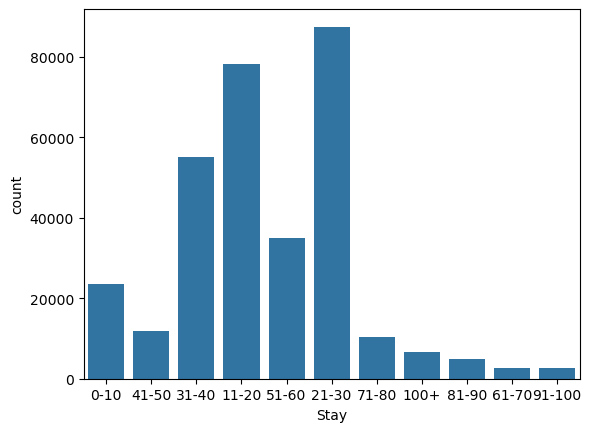

In [27]:
sns.countplot(x = 'Stay',data = df)

<Axes: xlabel='Hospital_code', ylabel='count'>

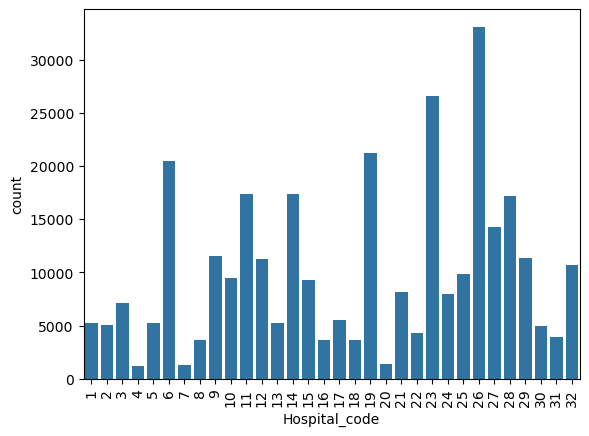

In [28]:
plt.xticks(rotation = 90)
sns.countplot(x = 'Hospital_code',data = df)

<Axes: xlabel='City_Code_Hospital', ylabel='count'>

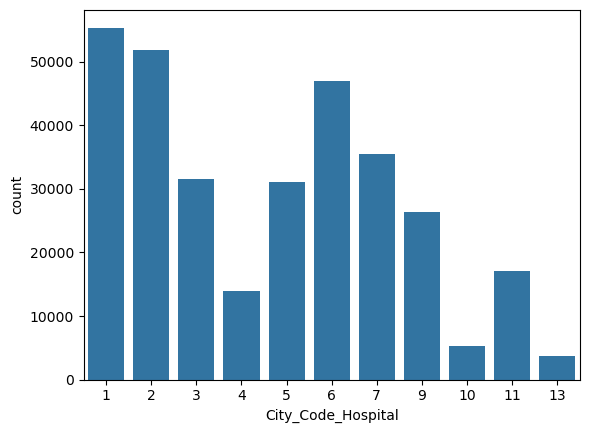

In [29]:
sns.countplot(x ='City_Code_Hospital',data = df)

<Axes: xlabel='Hospital_region_code', ylabel='count'>

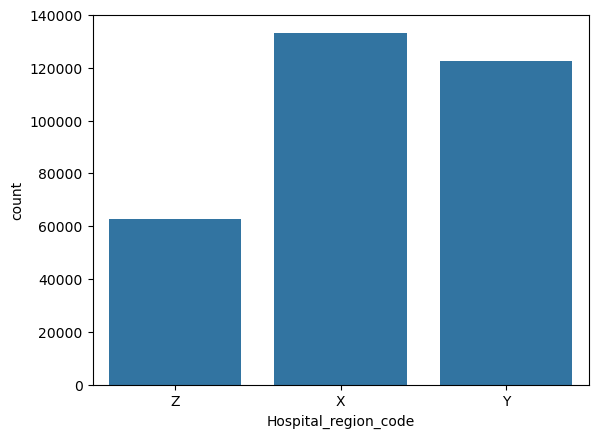

In [30]:
sns.countplot(x = 'Hospital_region_code',data = df)

<Axes: xlabel='Available_Extra_Rooms_in_Hospital', ylabel='count'>

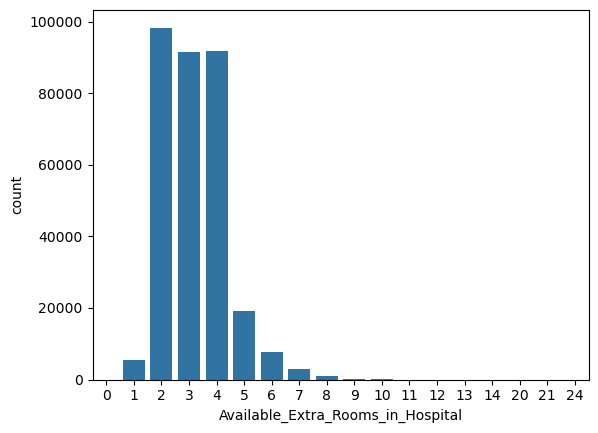

In [31]:
sns.countplot(x ='Available_Extra_Rooms_in_Hospital',data = df)

<Axes: xlabel='Department', ylabel='count'>

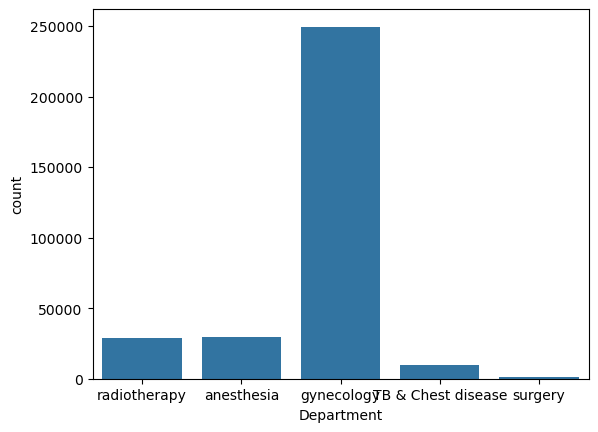

In [32]:
sns.countplot(x ='Department',data = df)

<Axes: xlabel='Ward_Type', ylabel='count'>

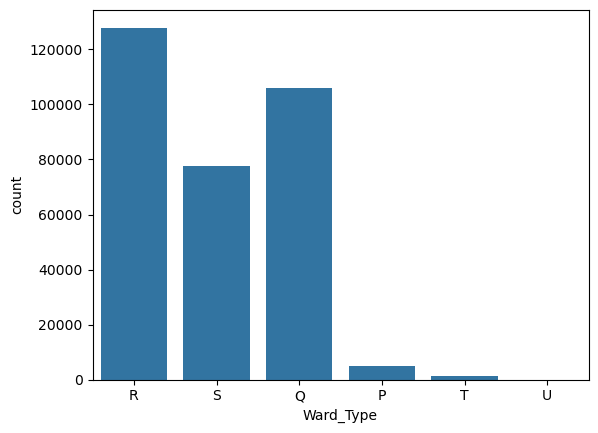

In [33]:
sns.countplot(x ='Ward_Type' ,data = df)

<Axes: xlabel='Ward_Facility_Code', ylabel='count'>

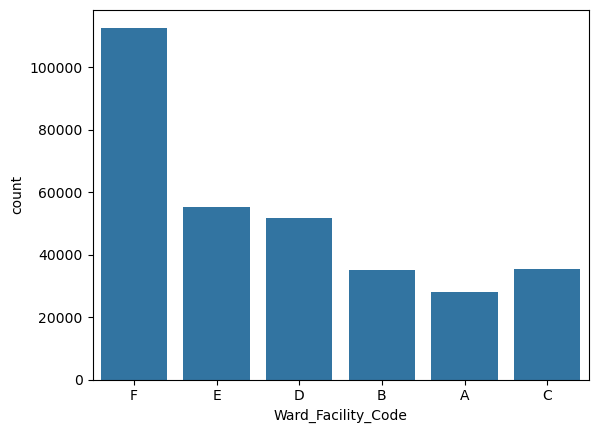

In [34]:
sns.countplot(x ='Ward_Facility_Code',data = df)

<Axes: xlabel='Bed_Grade', ylabel='count'>

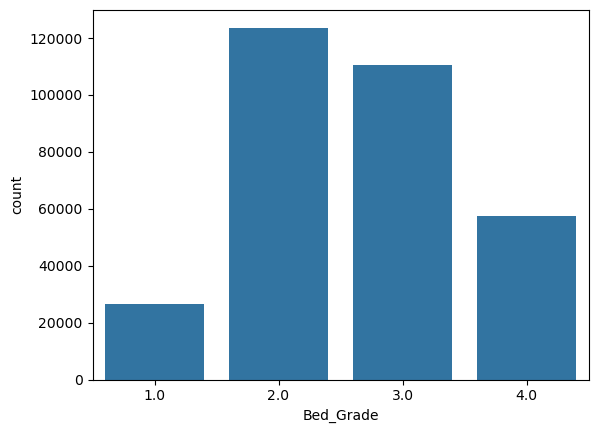

In [35]:
sns.countplot(x ='Bed_Grade',data = df)

<Axes: xlabel='City_Code_Patient', ylabel='count'>

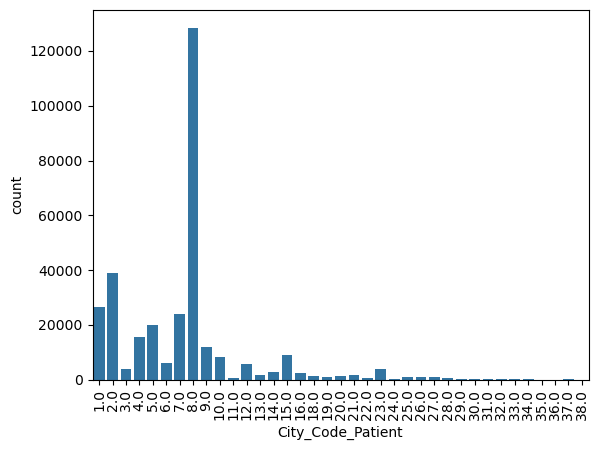

In [36]:
plt.xticks(rotation =90)
sns.countplot(x ='City_Code_Patient',data = df)

<Axes: xlabel='Type_of_Admission', ylabel='count'>

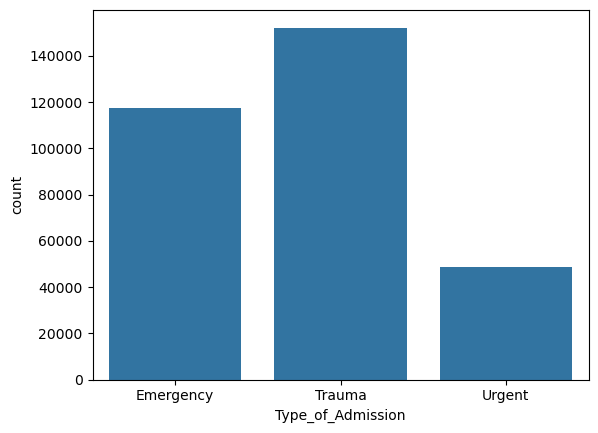

In [37]:
sns.countplot(x ='Type_of_Admission',data = df)

<Axes: xlabel='Severity_of_Illness', ylabel='count'>

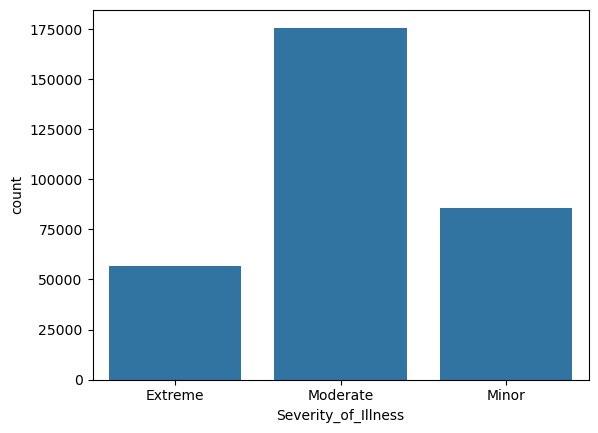

In [38]:
sns.countplot(x = 'Severity_of_Illness',data = df)

<Axes: xlabel='Visitors_with_Patient', ylabel='count'>

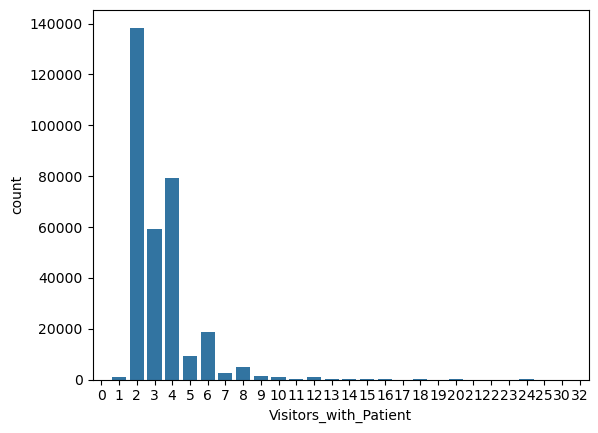

In [39]:
sns.countplot(x ='Visitors_with_Patient',data = df)

<Axes: xlabel='Age', ylabel='count'>

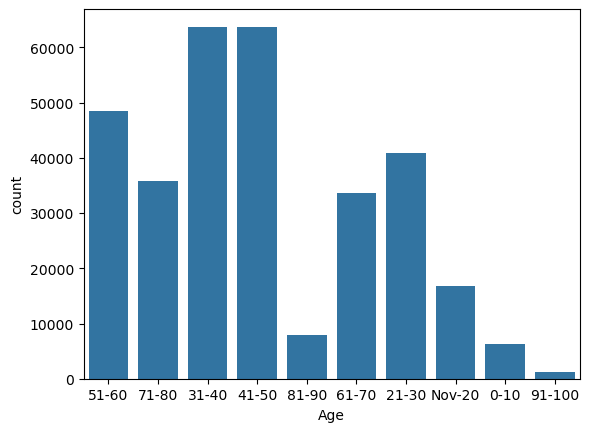

In [40]:
sns.countplot(x = 'Age',data = df)

### Insights
- Data related to patients stay between 0 to 60 days are more than 60 days.
- 2 to 4 extra rooms are mostly available in Hospitals. 
- Most of the patients were admitted in gynecology department.
- Mostly patients were admitted in 'R', 'S' and 'Q' type of ward.
- Most of the admission type was Trauma.
- Moderate severity of illness were highly recorded.
- Patients were mostly between age of 31-60 years.

<Axes: xlabel='Admission_Deposit', ylabel='Count'>

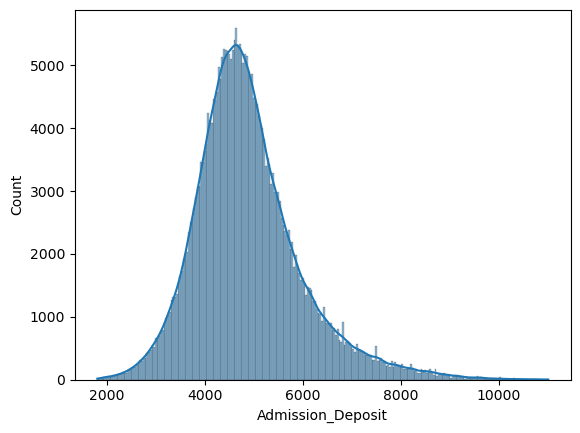

In [42]:
sns.histplot(x = df['Admission_Deposit'],kde = True)

## Insights
Admission deposit is the only numeric variable that has a fairly normal distribution. Hospital and Hospital City appear to have uniform distribution.

<Axes: xlabel='Stay', ylabel='count'>

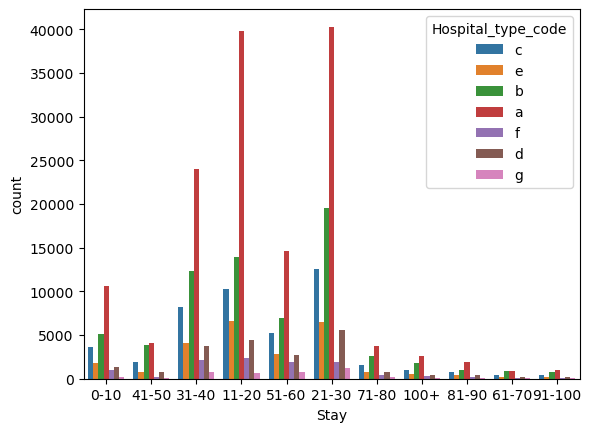

In [44]:
sns.countplot(x='Stay',hue='Hospital_type_code',data=df)

<Axes: xlabel='Stay', ylabel='count'>

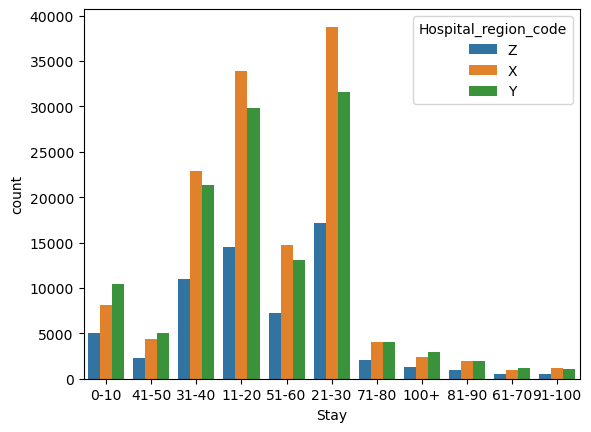

In [45]:
sns.countplot(x='Stay',hue='Hospital_region_code',data=df)

<Axes: xlabel='Stay', ylabel='count'>

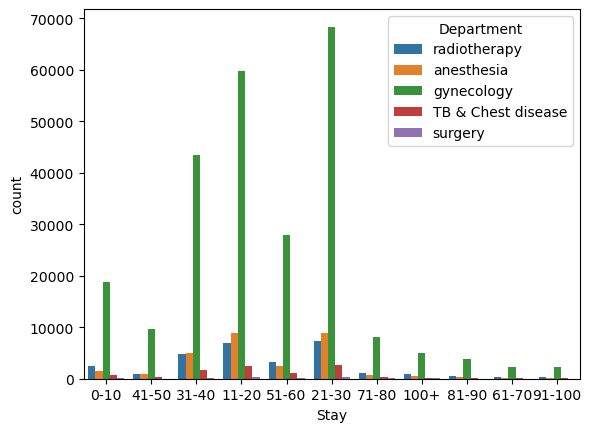

In [46]:
sns.countplot(x='Stay',hue='Department',data=df)

<Axes: xlabel='Stay', ylabel='count'>

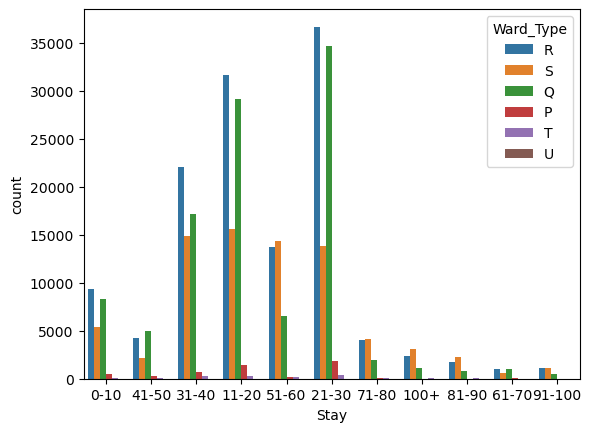

In [47]:
sns.countplot(x='Stay',hue='Ward_Type',data=df)

<Axes: xlabel='Stay', ylabel='count'>

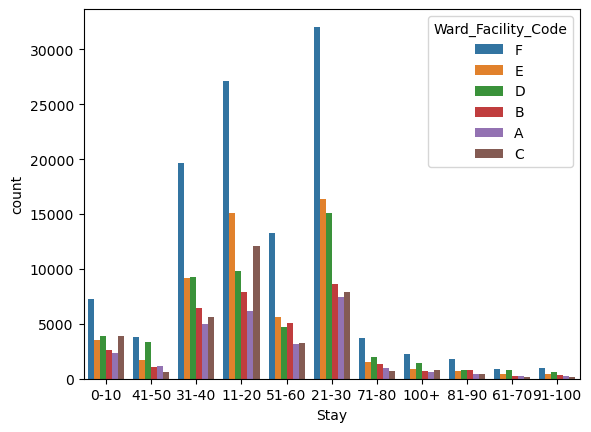

In [48]:
sns.countplot(x='Stay',hue='Ward_Facility_Code',data=df)

<Axes: xlabel='Stay', ylabel='count'>

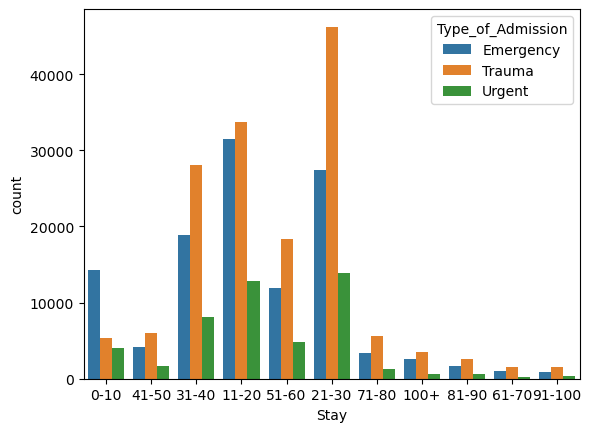

In [49]:
sns.countplot(x='Stay',hue='Type_of_Admission',data=df)

<Axes: xlabel='Stay', ylabel='count'>

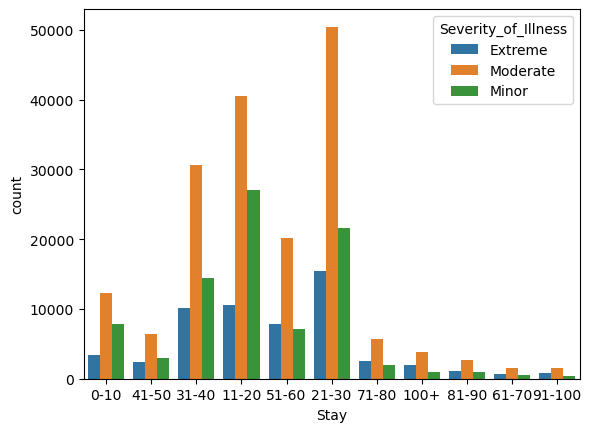

In [50]:
sns.countplot(x='Stay',hue='Severity_of_Illness',data=df)

<Axes: xlabel='Stay', ylabel='count'>

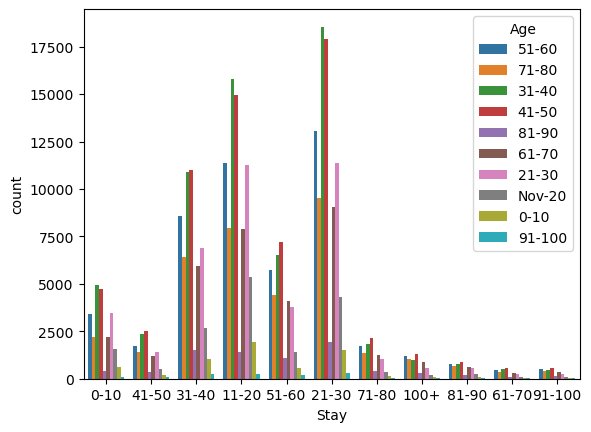

In [51]:
sns.countplot(x='Stay',hue='Age',data=df)

### Insights
-  In graph 1, Hospital type code a, b and c are in for every category of length of stay.
-  In graph 2, Hospital region code X and Y are in for every category of length of stay.
-  In graph 3, gynecology has the most observations with highest number of records for 21-30 Days Stay.
-  In graph 4, ward type R and Q recorded the most number of patients for 21-30 Days and 11-20 Days.
-  In graph 5, ward Facility code ward F and E has the most number of patients for 11-60 days.
-  In graph 6, patients suffering Trauma recorded the highest with 11-30 days.
-  In graph 7, patients with moderate and minor severity of illness recorded with highest number of days between 11-30 days.
-  In graph 8, patients aged between 31-50 recorded most number of stays between 11-30 days.

**Converting Categorical Data to Numberical Data**

In [54]:
from sklearn.preprocessing import LabelEncoder
LE = LabelEncoder()
df['Hospital_type_code'] = LE.fit_transform(df['Hospital_type_code'])
df['Hospital_region_code'] = LE.fit_transform(df['Hospital_region_code'])
df['Department'] = LE.fit_transform(df['Department'])
df['Ward_Type'] = LE.fit_transform(df['Ward_Type'])
df['Ward_Facility_Code'] = LE.fit_transform(df['Ward_Facility_Code'])
df['Type_of_Admission'] = LE.fit_transform(df['Type_of_Admission'])
df['Severity_of_Illness'] = LE.fit_transform(df['Severity_of_Illness'])
df['Age'] = LE.fit_transform(df['Age'])
df['Stay'] = LE.fit_transform(df['Stay'])

In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 318438 entries, 0 to 318437
Data columns (total 16 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Hospital_code                      318438 non-null  int64  
 1   Hospital_type_code                 318438 non-null  int32  
 2   City_Code_Hospital                 318438 non-null  int64  
 3   Hospital_region_code               318438 non-null  int32  
 4   Available_Extra_Rooms_in_Hospital  318438 non-null  int64  
 5   Department                         318438 non-null  int32  
 6   Ward_Type                          318438 non-null  int32  
 7   Ward_Facility_Code                 318438 non-null  int32  
 8   Bed_Grade                          318438 non-null  float64
 9   City_Code_Patient                  318438 non-null  float64
 10  Type_of_Admission                  318438 non-null  int32  
 11  Severity_of_Illness                3184

**Correlation Matrix**

<Axes: >

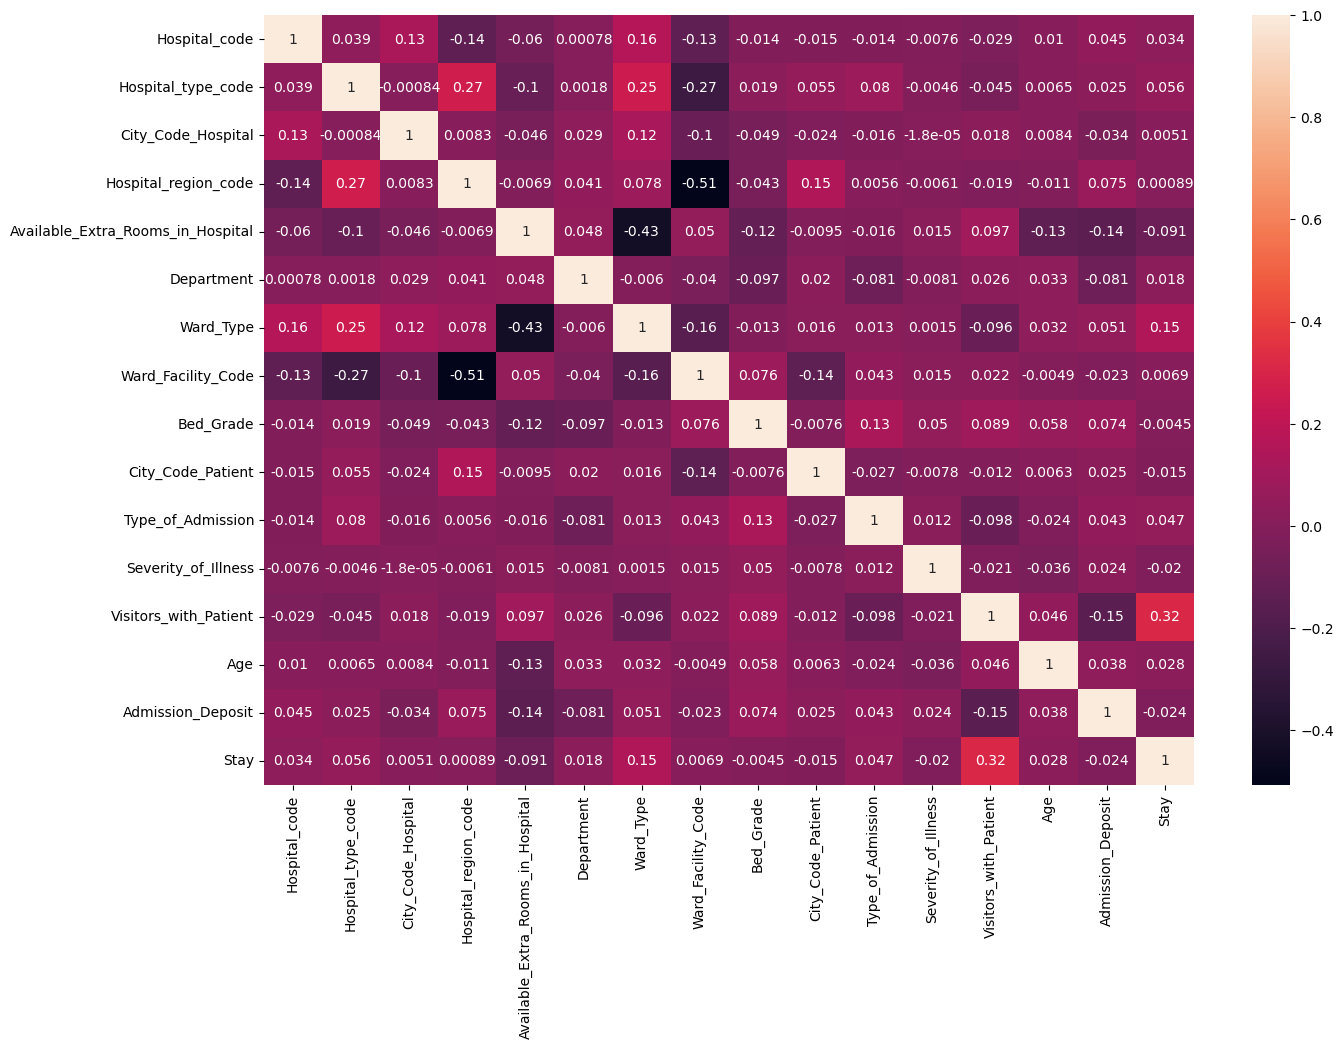

In [57]:
plt.figure(figsize = (15,10))
sns.heatmap(df.corr(),annot = True)

### Insights
Severity_of_Illness and Available_Extra_Rooms_in_Hospital has negative correlation with the target

## Modeling

In [60]:
final_res =[]

In [61]:
X = df.drop(['Stay'],axis =1)
y = df.Stay

In [62]:
from sklearn.model_selection import train_test_split
Xtrain,Xtest,y_train,y_test = train_test_split(X,y,test_size = 0.25,random_state = 42)

In [63]:
from sklearn.preprocessing import StandardScaler
SS = StandardScaler()
X_train = SS.fit_transform(Xtrain)
X_test = SS.transform(Xtest)

In [64]:
print(X_train.shape,X_test.shape,y_train.shape,y_test.shape)

(238828, 15) (79610, 15) (238828,) (79610,)


**Logistic Regression**

In [66]:
from sklearn.linear_model import LogisticRegression
LR = LogisticRegression()
LR.fit(X_train,y_train)

LogisticRegression()

In [67]:
y_pred_LR = LR.predict(X_test)

In [68]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [69]:
print('Logistic Regression :')
print('Accuracy Score: ', accuracy_score(y_test, y_pred_LR)*100)
print(classification_report(y_test, y_pred_LR))
acc_LR = accuracy_score(y_test, y_pred_LR)*100
final_res.append(acc_LR)

Logistic Regression :
Accuracy Score:  37.83067453837457
              precision    recall  f1-score   support

           0       0.47      0.03      0.05      5850
           1       0.52      0.34      0.41      1639
           2       0.36      0.40      0.38     19515
           3       0.40      0.68      0.50     21957
           4       0.33      0.19      0.24     13743
           5       0.00      0.00      0.00      2927
           6       0.36      0.47      0.41      8833
           7       0.00      0.00      0.00       709
           8       0.00      0.00      0.00      2539
           9       0.00      0.00      0.00      1215
          10       0.00      0.00      0.00       683

    accuracy                           0.38     79610
   macro avg       0.22      0.19      0.18     79610
weighted avg       0.34      0.38      0.33     79610



**Random Forest**

In [71]:
from sklearn.ensemble import RandomForestClassifier
RFC = RandomForestClassifier()
RFC.fit(X_train,y_train)

RandomForestClassifier()

In [72]:
y_pred_RFC = RFC.predict(X_test)

In [73]:
print('Random Forest :')
print('Accuracy Score :',accuracy_score(y_test,y_pred_RFC)*100)
print(classification_report(y_test, y_pred_RFC))
acc_RFC = accuracy_score(y_test, y_pred_RFC)*100
final_res.append(acc_RFC)

Random Forest :
Accuracy Score : 38.30046476573295
              precision    recall  f1-score   support

           0       0.29      0.19      0.23      5850
           1       0.52      0.45      0.48      1639
           2       0.39      0.44      0.41     19515
           3       0.41      0.53      0.47     21957
           4       0.33      0.27      0.29     13743
           5       0.11      0.03      0.04      2927
           6       0.40      0.46      0.42      8833
           7       0.07      0.01      0.02       709
           8       0.28      0.10      0.14      2539
           9       0.37      0.18      0.24      1215
          10       0.28      0.06      0.10       683

    accuracy                           0.38     79610
   macro avg       0.31      0.25      0.26     79610
weighted avg       0.36      0.38      0.37     79610



**Decision Tree**

In [75]:
from sklearn.tree import DecisionTreeClassifier
DTC = DecisionTreeClassifier()
DTC.fit(X_train,y_train)

DecisionTreeClassifier()

In [76]:
y_pred_DTC = DTC.predict(X_test)

In [77]:
print('Decision Tree :')
print('Accuracy Score: ', accuracy_score(y_test, y_pred_DTC)*100)
print(classification_report(y_test, y_pred_DTC))
acc_DTC = accuracy_score(y_test, y_pred_DTC)*100
final_res.append(acc_DTC)

Decision Tree :
Accuracy Score:  29.47117196332119
              precision    recall  f1-score   support

           0       0.19      0.19      0.19      5850
           1       0.35      0.35      0.35      1639
           2       0.34      0.34      0.34     19515
           3       0.38      0.37      0.38     21957
           4       0.24      0.25      0.25     13743
           5       0.06      0.07      0.07      2927
           6       0.30      0.31      0.30      8833
           7       0.03      0.03      0.03       709
           8       0.14      0.15      0.14      2539
           9       0.22      0.23      0.22      1215
          10       0.10      0.11      0.10       683

    accuracy                           0.29     79610
   macro avg       0.21      0.22      0.22     79610
weighted avg       0.30      0.29      0.30     79610



**K-Nearest Neighbors**

In [79]:
from sklearn.neighbors import KNeighborsClassifier
KNN = KNeighborsClassifier()
KNN.fit(X_train,y_train)

KNeighborsClassifier()

In [80]:
y_pred_KNN = KNN.predict(X_test)

In [81]:
print('K-Nearest Neighbors : ')
print('Accuracy Score: ', accuracy_score(y_test, y_pred_KNN)*100)
print(classification_report(y_test, y_pred_KNN))
acc_KNN = accuracy_score(y_test, y_pred_KNN)*100
final_res.append(acc_KNN)

K-Nearest Neighbors : 
Accuracy Score:  33.49453586232885
              precision    recall  f1-score   support

           0       0.19      0.20      0.20      5850
           1       0.38      0.39      0.38      1639
           2       0.34      0.46      0.39     19515
           3       0.39      0.46      0.42     21957
           4       0.28      0.22      0.25     13743
           5       0.07      0.01      0.02      2927
           6       0.36      0.28      0.31      8833
           7       0.06      0.00      0.01       709
           8       0.17      0.06      0.09      2539
           9       0.25      0.08      0.12      1215
          10       0.17      0.03      0.05       683

    accuracy                           0.33     79610
   macro avg       0.24      0.20      0.20     79610
weighted avg       0.32      0.33      0.32     79610



**GradientBoosting**

In [83]:
from sklearn.ensemble import GradientBoostingClassifier
GBC = GradientBoostingClassifier()
GBC.fit(X_train,y_train)

GradientBoostingClassifier()

In [84]:
y_pred_GBC = GBC.predict(X_test)

In [85]:
print('GradientBoosting : ')
print('Accuracy Score: ', accuracy_score(y_test, y_pred_GBC)*100)
print(classification_report(y_test, y_pred_GBC))
acc_GBC = accuracy_score(y_test, y_pred_GBC)*100
final_res.append(acc_GBC)

GradientBoosting : 
Accuracy Score:  41.49981158145962
              precision    recall  f1-score   support

           0       0.40      0.12      0.19      5850
           1       0.49      0.42      0.45      1639
           2       0.41      0.51      0.46     19515
           3       0.43      0.65      0.52     21957
           4       0.41      0.18      0.25     13743
           5       0.25      0.00      0.00      2927
           6       0.39      0.52      0.45      8833
           7       0.00      0.00      0.00       709
           8       0.29      0.01      0.01      2539
           9       0.31      0.19      0.23      1215
          10       0.32      0.01      0.02       683

    accuracy                           0.41     79610
   macro avg       0.34      0.24      0.23     79610
weighted avg       0.40      0.41      0.37     79610



**AdaBoosting**

In [87]:
from sklearn.ensemble import AdaBoostClassifier
ADA = AdaBoostClassifier()
ADA.fit(X_train,y_train)

AdaBoostClassifier()

In [88]:
y_pred_ADA = ADA.predict(X_test)

In [89]:
print('AdaBoosting : ')
print('Accuracy Score: ', accuracy_score(y_test, y_pred_ADA)*100)
print(classification_report(y_test, y_pred_ADA))
acc_ADA = accuracy_score(y_test, y_pred_ADA)*100
final_res.append(acc_ADA)

AdaBoosting : 
Accuracy Score:  37.37093329983671
              precision    recall  f1-score   support

           0       0.21      0.11      0.15      5850
           1       0.38      0.40      0.39      1639
           2       0.37      0.39      0.38     19515
           3       0.41      0.64      0.50     21957
           4       0.32      0.22      0.26     13743
           5       0.00      0.00      0.00      2927
           6       0.37      0.41      0.39      8833
           7       0.00      0.00      0.00       709
           8       0.00      0.00      0.00      2539
           9       0.08      0.01      0.02      1215
          10       0.00      0.00      0.00       683

    accuracy                           0.37     79610
   macro avg       0.19      0.20      0.19     79610
weighted avg       0.32      0.37      0.34     79610



## Comparing Algorithm

Text(0.5, 1.0, 'Accuracy Score')

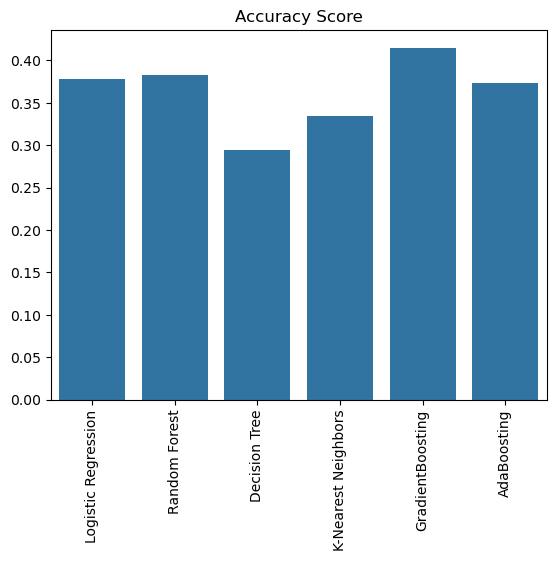

In [91]:
plt.xticks(rotation = 90)
sns.barplot(x = ['Logistic Regression', 'Random Forest','Decision Tree','K-Nearest Neighbors','GradientBoosting','AdaBoosting'], y = [accuracy_score(y_test, y_pred_LR), accuracy_score(y_test, y_pred_RFC), accuracy_score(y_test, y_pred_DTC), accuracy_score(y_test, y_pred_KNN),accuracy_score(y_test, y_pred_GBC),accuracy_score(y_test, y_pred_ADA)]).set_title('Accuracy Score')

In [92]:
final=np.array(final_res)
result=final.reshape(-1,1)
columns=['Accuracy']
index=['Logistic Regression', 'Random Forest','Decision Tree','K-Nearest Neighbors','GradientBoosting','AdaBoosting']
final_result=pd.DataFrame(result,index=index,columns=columns)
final_result.sort_values(by='Accuracy', ascending=False)

,Accuracy
GradientBoosting,41.499812
Random Forest,38.300465
Logistic Regression,37.830675
AdaBoosting,37.370933
K-Nearest Neighbors,33.494536
Decision Tree,29.471172


## Hyperparameter optimization

#### Tuning Best Performing Models

**GradientBoosting**

In [93]:
from sklearn.model_selection import RandomizedSearchCV

In [94]:
grid_XGB=GradientBoostingClassifier(n_estimators=65, max_depth=6, learning_rate=0.7)
grid_XGB.fit(X_train, y_train)

GradientBoostingClassifier(learning_rate=0.7, max_depth=6, n_estimators=65)

In [95]:
y_pred_grid_XGB = grid_XGB.predict(X_test)
y_pred_grid_XGB_train = grid_XGB.predict(X_train)

In [96]:
print('Accuracy Score: ', accuracy_score(y_test, y_pred_grid_XGB))
print('F1 Score (Micro) on Training Data :', f1_score(y_train, y_pred_grid_XGB_train, average='micro'))
print('F1 Score (Micro) on Testing Data :', f1_score(y_test, y_pred_grid_XGB, average='micro'))

Accuracy Score:  0.39790227358372066
F1 Score (Micro) on Training Data : 0.4588406719480128
F1 Score (Micro) on Testing Data : 0.39790227358372066


**Random Forest**

In [103]:
from sklearn.model_selection import RandomizedSearchCV
grid_rf = RandomForestClassifier(max_depth=3,
                                    max_features="log2",
                                    max_leaf_nodes=3,
                                    n_estimators=50)
grid_rf.fit(X_train,y_train)

RandomForestClassifier(max_depth=3, max_features='log2', max_leaf_nodes=3,
                       n_estimators=50)

In [105]:
y_pred_grid_rf = grid_rf.predict(X_test)
y_pred_grid_rf_train = grid_rf.predict(X_train)

In [107]:
print('Accuracy Score: ', accuracy_score(y_test, y_pred_grid_rf))
print('F1 Score (Micro) on Training Data :', f1_score(y_train, y_pred_grid_rf_train, average='micro'))
print('F1 Score (Micro) on Testing Data :', f1_score(y_test, y_pred_grid_rf, average='micro'))

Accuracy Score:  0.2846501695766863
F1 Score (Micro) on Training Data : 0.2830405145125362
F1 Score (Micro) on Testing Data : 0.2846501695766863


## Conclusion
After the parameter tuning process with GradientBoosting and Random Forest, the F1 score value obtained for all the two models on the training data and validation data. It can be seen that the model on Random Forest is more stable because the F1 score value on the training data and validation data is in the range of 28.30% and 28.46%. While in the GradientBoosting model, the F1 score value on the training data is 45.88% and 39.79% on the validation data,.As the model, we will use Random Forest model to predict the test data.

The process of predictinthe length of stay (in days) of a patient entering the Hospital can be predicted using the Machine Learning algorithm. The model with the highest Accuracy Score in predicting the length of stay (in days) of a patient entering the Hospital is the Random Forest model using the RandomForestClassifier. Using this model, the Accuracy Score value is 28.46%.%.

## Report on Challenges faced
Challenges faced for predicting the length of stay (in days) of a patient entering the Hospital is Slow Implementation i.e. it takes a tremendous amount of time. Also poor Quality of data i.e. it contains unclean and noisy data.
